In [1]:
import pandas as pd
from src.data_processing import clean_raw_data
from src.modeling import stratified_cv
from sklearn.metrics import accuracy_score
from src.fairness import get_threshold, fairness_data, run_fairness_audit, print_fairness_audit, get_thresholds_per_group, apply_group_thresholds, plot_fairness_tradeoff, save_thresholds
from src.fairness import save_metrics

In [2]:
raw_data = pd.read_csv('../data/raw/credit_risk_dataset.csv')
cleaned_data = clean_raw_data(raw_data)

num_cols_b = ["person_age", "person_income", "person_emp_length", "loan_amnt",
              "loan_percent_income", "cb_person_cred_hist_length"]
cat_cols_b = ["person_home_ownership", "loan_intent", "cb_person_default_on_file"]

metrics_b, oof_proba = stratified_cv(cleaned_data, num_cols_b, cat_cols_b, return_oof=True)
print(f"OOF-based Gini check: {2*metrics_b['mean_roc_auc']-1:.4f}")

y_true = cleaned_data["loan_status"]

OOF-based Gini check: 0.7336


In [3]:
threshold = get_threshold(y_true, oof_proba)
y_pred = (oof_proba >= threshold).astype(int)

print(f"Chosen threshold: {threshold:.3f}")
print(f"Approval rate at this threshold: {(1 - y_pred.mean()):.1%}")

Chosen threshold: 0.220
Approval rate at this threshold: 75.9%


In [4]:
X_raw = cleaned_data[num_cols_b + cat_cols_b]
df_fair = fairness_data(X_raw)

group_cols = ['age_group', 'person_home_ownership', 'loan_intent']

In [5]:
audit_results = run_fairness_audit(y_true, y_pred, df_fair, group_cols)
print_fairness_audit(audit_results)

________________________________________
AI FAIRNESS AUDIT REPORT
________________________________________

--- Attribute: AGE_GROUP ---

Detailed Metrics by Group:
                selection_rate  true_positive_rate
age_group                                         
middle (26-40)        0.225693            0.666769
older (40+)           0.232840            0.698113
young (18-25)         0.257724            0.709385

Approval Rate & Group Size:
                approval_rate  group_size
age_group                                
middle (26-40)       0.774307       15685
older (40+)          0.767160        1486
young (18-25)        0.742276       15245

Headline Fairness Indicators:
 Disparate Impact Ratio (DIR): 0.96
 Equal Opportunity Diff (EOD): 0.04
 PASS: DIR is acceptable (>= 0.80)
 PASS: EOD is acceptable (<= 0.10)

--- Attribute: PERSON_HOME_OWNERSHIP ---

Detailed Metrics by Group:
                       selection_rate  true_positive_rate
person_home_ownership                   

In [6]:
group_thresholds = get_thresholds_per_group(
    y_true, oof_proba, df_fair['person_home_ownership']
)
print("Thresholds per group:", group_thresholds)

save_thresholds(group_thresholds, filepath="../models/group_thresholds.json")

Thresholds per group: {'RENT': np.float64(0.23968843799052708), 'OWN': np.float64(0.15875676126855798), 'MORTGAGE': np.float64(0.16290407699285045), 'OTHER': np.float64(0.1973591041055578)}
Thresholds saved to ../models/group_thresholds.json


In [7]:
y_pred_fair = apply_group_thresholds(
    oof_proba, df_fair['person_home_ownership'], group_thresholds
)

In [8]:
# Ячейка 8 — сравниваем аудит ДО и ПОСЛЕ
print("BEFORE:")
print_fairness_audit(run_fairness_audit(y_true, y_pred, df_fair, ['person_home_ownership']))

print("\nAFTER:")
print_fairness_audit(run_fairness_audit(y_true, y_pred_fair, df_fair, ['person_home_ownership']))

BEFORE:
________________________________________
AI FAIRNESS AUDIT REPORT
________________________________________

--- Attribute: PERSON_HOME_OWNERSHIP ---

Detailed Metrics by Group:
                       selection_rate  true_positive_rate
person_home_ownership                                    
MORTGAGE                     0.120129            0.382928
OTHER                        0.235849            0.515152
OWN                          0.069060            0.786458
RENT                         0.366772            0.786749

Approval Rate & Group Size:
                       approval_rate  group_size
person_home_ownership                           
MORTGAGE                    0.879871       13369
OTHER                       0.764151         106
OWN                         0.930940        2563
RENT                        0.633228       16378

Headline Fairness Indicators:
 Disparate Impact Ratio (DIR): 0.68
 Equal Opportunity Diff (EOD): 0.40
 FLAG: DIR is below 0.80 (Potential Dispa

Accuracy BEFORE: 0.8417
Accuracy AFTER:  0.7956


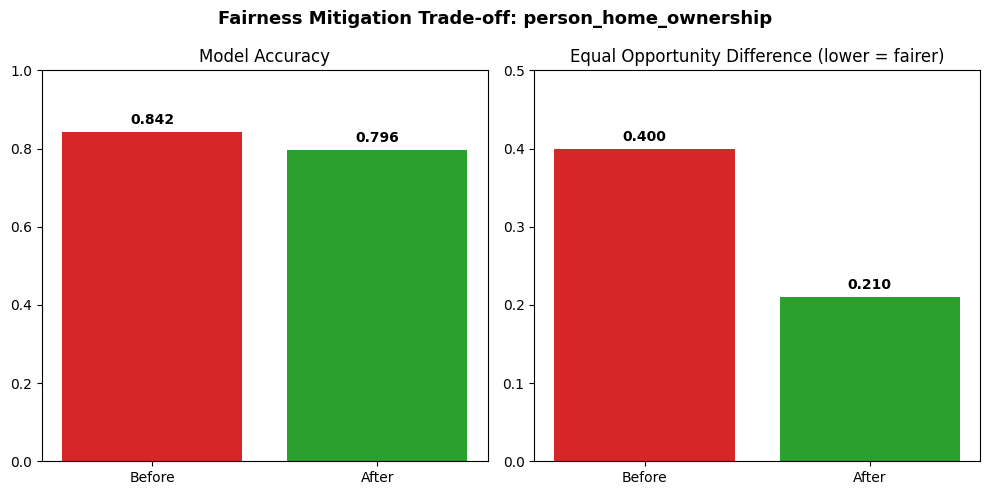

In [9]:

acc_before = accuracy_score(y_true, y_pred)
acc_after = accuracy_score(y_true, y_pred_fair)

eod_before = 0.40  # из твоего аудита ДО
eod_after = 0.21   # из твоего аудита ПОСЛЕ

print(f"Accuracy BEFORE: {acc_before:.4f}")
print(f"Accuracy AFTER:  {acc_after:.4f}")

plot_fairness_tradeoff(acc_before, acc_after, eod_before, eod_after)

In [10]:
final_metrics = {
    "model_performance": {
        "oof_roc_auc": float(metrics_b["mean_roc_auc"]),
        "oof_gini": float(metrics_b["mean_gini"]),
        "oof_pr_auc": float(metrics_b["mean_pr_auc"]),
        "decision_threshold": float(threshold)
    },
    "fairness_audit": {
        "age_group": {"DIR": 0.96, "EOD": 0.04},
        "loan_intent": {"DIR": 0.79, "EOD": 0.07},
        "person_home_ownership_before": {"DIR": 0.68, "EOD": 0.40},
        "person_home_ownership_after": {"DIR": 0.74, "EOD": 0.21}
    },
    "mitigation_tradeoff": {
        "accuracy_before": float(acc_before),
        "accuracy_after": float(acc_after)
    }
}

save_metrics(final_metrics, filepath="../models/model_metrics.json")

Metrics saved to ../models/model_metrics.json
